# When to hold more cash, how much, and when to put it back

The question from the person using RADAR: *"Tell me when to switch to cash-heavy and
what percentage, when to buy again with the cash, and how to rebalance, taking account
of Fed and macro news and of indicators like the stochastic (5,3,3), fair value gaps
and order blocks."*

Notebooks 11 and 12 found no way to say which way a price goes next. They also
*noticed* something that does not need that: two simple rules made the worst fall much
shallower in Bitcoin and US stocks. Noticing is not testing, and those were the same
three markets everything had been tried on. So this notebook tests it properly, on
**24 markets none of these rules has been run on**.

**The core rule.** Two parts, multiplied:

| part | says |
|---|---|
| swings | hold min(100%, usual swing / current swing): less when the last 20 days were rougher than usual |
| 200-day average | hold everything while the close is above it, nothing while below |

The result is a share to hold; the rest is cash. That is the answer to "when, and what
percentage".

**Three claims, written down before running** (`docs/DECISIONS.md`, entry 064):

1. The core rule makes the deepest fall shallower.
2. News and indicators improve on it: stepping back around Fed, jobs and inflation
   releases; and using the stochastic, fair value gaps or order blocks to decide when
   to put the cash back.
3. It works on a whole portfolio, not just one market at a time.

Rebuild with `uv run python backend/scripts/build_notebooks.py 13_cash_share`
(reads `data/research/`; the first run fetches it and needs the keys in `.env`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

from radar.analytics import events
from radar.analytics import technical as ta
from radar.config import load_settings
from radar.pipelines import research
from radar.providers.alpaca_rest import AlpacaDataClient
from radar.signals import track
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.2f}")
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 120)
GROUPS = {
    "stocks": ["QQQ", "IWM", "EFA", "EEM", "XLE", "XLF", "XLK", "XLV", "XLU", "VNQ"],
    "bonds": ["TLT", "IEF", "LQD", "HYG"],
    "commodities": ["SLV", "USO", "DBC", "DBA"],
    "crypto": ["ETH/USD", "SOL/USD", "LTC/USD", "LINK/USD", "AVAX/USD", "DOGE/USD"],
}
GROUP_OF = {symbol: group for group, symbols in GROUPS.items() for symbol in symbols}
COLOURS = {"stocks": "tab:blue", "bonds": "tab:green", "commodities": "goldenrod", "crypto": "tab:orange"}
SYMBOLS = list(GROUP_OF)
DATES = sorted({d for kind in events.get_events() for d in kind.dates})

settings = load_settings()
missing = [s for s in SYMBOLS if not research.path_of(s).exists()]
if missing:
    with AlpacaDataClient(settings.alpaca_api_key_id, settings.alpaca_api_secret_key) as client:
        bars = research.load(SYMBOLS, client, get_universe().crypto_location)
else:
    bars = research.load(SYMBOLS, None, "")
bars = {s: f for s, f in bars.items() if len(f) >= 750}
print("Left out for too short a record:", [s for s in SYMBOLS if s not in bars] or "none")
YEAR = {s: 365 if research.is_crypto(s) else 252 for s in bars}
pd.DataFrame(
    [{"market": s, "group": GROUP_OF[s], "days": len(f), "from": f.index[0].date(), "to": f.index[-1].date()} for s, f in bars.items()]
).groupby("group").agg(markets=("market", lambda m: ", ".join(m)), days=("days", "median"), start=("from", "min"), end=("to", "max"))

Left out for too short a record: none


,markets,days,start,end
group,,,,
bonds,"TLT, IEF, LQD, HYG",2705.00,2016-01-04,2026-10-06
commodities,"SLV, USO, DBC, DBA",2705.00,2016-01-04,2026-10-06
crypto,"ETH/USD, SOL/USD, LTC/USD, LINK/USD, AVAX/USD,...",2105.00,2021-01-01,2026-10-06
stocks,"QQQ, IWM, EFA, EEM, XLE, XLF, XLK, XLV, XLU, VNQ",2705.00,2016-01-04,2026-10-06


## 1. What the core rule does, on one market

The Nasdaq 100 fund (QQQ), with the share the rule would hold underneath. It steps
down when swings rise and steps out below the 200-day average.

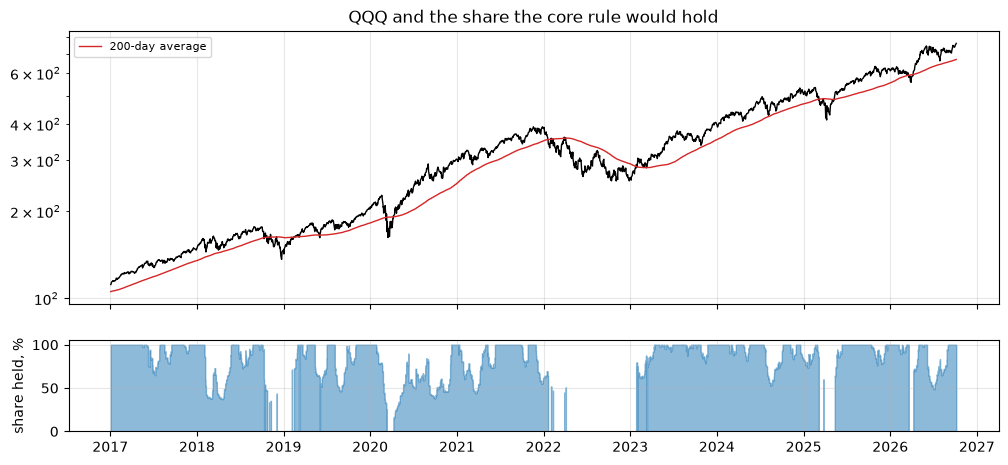

In [2]:
def shares(symbol):
    """Every rule's share to hold, decided at each day's close."""
    frame = bars[symbol]
    close, returns = frame["close"], frame["close"].pct_change()
    swings = ta.hold_by_swings(returns)
    average = ta.hold_above_average(close)
    core = swings * average
    index = pd.DatetimeIndex(frame.index)
    rules = {
        "swings": swings,
        "200-day": average,
        "core": core,
        "core + events": core * ta.hold_through_events(index, DATES),
        "core + stochastic": ta.hold_with_reentry(core, ta.stochastic_cases(frame["high"], frame["low"], close)),
        "core + fair value gap": ta.hold_with_reentry(core, ta.fair_value_gap_cases(frame["high"], frame["low"], up=True)),
        "core + order block": ta.hold_with_reentry(core, ta.order_block_cases(frame, up=True)),
    }
    return {name: weight.iloc[ta.WARM_UP :] for name, weight in rules.items()}


symbol = "QQQ"
weight = shares(symbol)["core"]
close = bars[symbol]["close"].loc[weight.index]
fig, (top, bottom) = plt.subplots(2, 1, figsize=(12, 5.2), sharex=True, height_ratios=[3, 1])
top.plot(close.index, close, color="black", lw=1)
top.plot(close.index, ta.sma(bars[symbol]["close"], 200).loc[close.index], color="tab:red", lw=1, label="200-day average")
top.set(title="QQQ and the share the core rule would hold", yscale="log")
top.legend(fontsize=8)
bottom.fill_between(weight.index, weight * 100, step="post", color="tab:blue", alpha=0.5)
bottom.set(ylabel="share held, %", ylim=(0, 105));

## 2. Claim 1: does the core rule make the deepest fall shallower?

For each of the 24 markets: the worst fall from a high while simply holding, and the
worst fall while following each rule, over the same days and after costs.

In [3]:
ALL_RULES = ["swings", "200-day", "core", "core + events", "core + stochastic", "core + fair value gap", "core + order block"]
rows, nets = [], {}
for symbol, frame in bars.items():
    returns = frame["close"].pct_change()
    rules = shares(symbol)
    days = rules["core"].index
    hold = ta.backtest(returns.loc[days], pd.Series(1.0, index=days))
    years = len(hold) / YEAR[symbol]
    nets[symbol] = {"holding": hold}
    row = {"market": symbol, "group": GROUP_OF[symbol], "holding fall %": ta.deepest_fall(hold) * 100,
           "holding ret/yr %": ((1 + hold).prod() ** (1 / years) - 1) * 100, "holding Sharpe": ta.sharpe(hold, YEAR[symbol])}
    for name in ALL_RULES:
        net = ta.backtest(returns.loc[days], rules[name])
        nets[symbol][name] = net
        row[f"{name} fall %"] = ta.deepest_fall(net) * 100
        row[f"{name} ret/yr %"] = ((1 + net).prod() ** (1 / years) - 1) * 100
        row[f"{name} Sharpe"] = ta.sharpe(net, YEAR[symbol])
        row[f"{name} held %"] = rules[name].shift(1).reindex(net.index).mean() * 100
    rows.append(row)
table = pd.DataFrame(rows).set_index("market")
table[["group", "holding fall %", "core fall %", "holding ret/yr %", "core ret/yr %", "holding Sharpe", "core Sharpe", "core held %"]]

,group,holding fall %,core fall %,holding ret/yr %,core ret/yr %,holding Sharpe,core Sharpe,core held %
market,,,,,,,,
QQQ,stocks,-35.00,-15.21,21.77,15.10,0.98,1.13,70.92
IWM,stocks,-41.27,-26.36,9.13,2.68,0.50,0.27,62.40
EFA,stocks,-34.20,-24.58,9.33,4.11,0.60,0.45,67.87
EEM,stocks,-39.82,-30.22,9.27,5.80,0.53,0.52,61.34
XLE,stocks,-66.82,-44.24,9.86,1.53,0.47,0.18,55.60
XLF,stocks,-42.86,-24.99,10.94,4.46,0.58,0.41,66.62
XLK,stocks,-33.56,-14.77,25.51,17.12,1.02,1.17,68.83
XLV,stocks,-28.40,-28.84,11.21,1.85,0.72,0.23,68.20
XLU,stocks,-36.09,-29.22,8.95,3.17,0.55,0.33,67.13


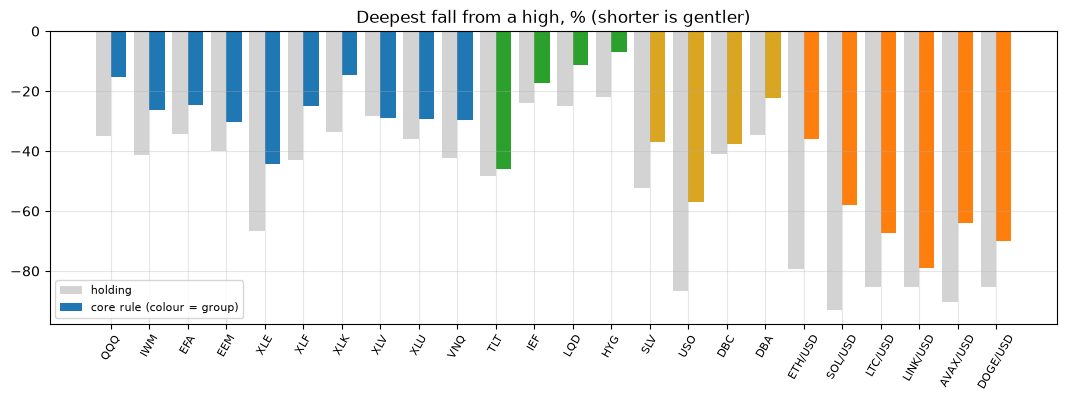

In [4]:
fig, ax = plt.subplots(figsize=(13, 3.8))
x = np.arange(len(table))
ax.bar(x - 0.2, table["holding fall %"], width=0.4, color="lightgrey", label="holding")
ax.bar(x + 0.2, table["core fall %"], width=0.4, color=[COLOURS[g] for g in table["group"]], label="core rule (colour = group)")
ax.set_xticks(x, table.index, rotation=60, fontsize=8)
ax.set(title="Deepest fall from a high, % (shorter is gentler)")
ax.legend(fontsize=8);

In [5]:
rows = []
for name in ("swings", "200-day", "core"):
    gain = table[f"{name} fall %"] - table["holding fall %"]  # above zero: shallower
    by_group = gain.groupby(table["group"]).median()
    rows.append({
        "rule": name,
        "shallower in % of markets": (gain > 0).mean() * 100,
        "median improvement, points": gain.median(),
        "p": wilcoxon(gain).pvalue,
        "groups shallower (of 4)": int((by_group > 0).sum()),
        **{f"{g}, points": by_group[g] for g in GROUPS},
        "median return given up, points/yr": (table["holding ret/yr %"] - table[f"{name} ret/yr %"]).median(),
        "Sharpe higher in % of markets": (table[f"{name} Sharpe"] > table["holding Sharpe"]).mean() * 100,
    })
claim1 = pd.DataFrame(rows)
passing = track.survivors([(i, 0, p) for i, p in enumerate(claim1["p"])], 0.05)
claim1["survives"] = [(i, 0) in passing for i in range(len(claim1))]
claim1["passes"] = (claim1["shallower in % of markets"] >= 70) & claim1["survives"] & (claim1["median improvement, points"] > 0) & (claim1["groups shallower (of 4)"] >= 3)
claim1.set_index("rule").T

rule,swings,200-day,core
shallower in % of markets,100.00,87.50,95.83
"median improvement, points",9.75,11.25,14.94
p,0.00,0.00,0.00
groups shallower (of 4),4,4,4
"stocks, points",12.58,9.67,13.85
"bonds, points",9.05,7.76,10.24
"commodities, points",13.40,9.17,13.82
"crypto, points",2.23,18.90,22.11
"median return given up, points/yr",1.30,2.97,3.00
Sharpe higher in % of markets,50.00,25.00,25.00


## 3. Claim 2: do news and indicators improve on the core rule?

Four add-ons, each set against the core rule alone:

| add-on | what it changes |
|---|---|
| events | halve the share the day before and the day of a Fed decision, jobs report, or inflation report |
| stochastic (5,3,3) | when some cash is held and the fast line crosses up from under 20, hold everything for 5 days |
| fair value gap | the same, when price first returns to an up-gap |
| order block | the same, when price first returns to an up-block |

The last three are the test of "when to buy with the cash".

In [6]:
ADD_ONS = ["core + events", "core + stochastic", "core + fair value gap", "core + order block"]
rows = []
for name in ADD_ONS:
    sharpe_gain = table[f"{name} Sharpe"] - table["core Sharpe"]
    fall_gain = table[f"{name} fall %"] - table["core fall %"]
    rows.append({
        "add-on": name,
        "Sharpe higher in % of markets": (sharpe_gain > 0).mean() * 100,
        "median Sharpe change": sharpe_gain.median(),
        "p": wilcoxon(sharpe_gain).pvalue,
        "median change in deepest fall, points": fall_gain.median(),
        "median return change, points/yr": (table[f"{name} ret/yr %"] - table["core ret/yr %"]).median(),
        "share held, core %": table["core held %"].median(),
        "share held, with add-on %": table[f"{name} held %"].median(),
    })
claim2 = pd.DataFrame(rows)
passing = track.survivors([(i, 0, p) for i, p in enumerate(claim2["p"])], 0.05)
claim2["survives"] = [(i, 0) in passing for i in range(len(claim2))]
claim2["passes"] = (claim2["Sharpe higher in % of markets"] >= 70) & claim2["survives"] & (claim2["median Sharpe change"] > 0) & (claim2["median change in deepest fall, points"] >= 0)
claim2.set_index("add-on").T

add-on,core + events,core + stochastic,core + fair value gap,core + order block
Sharpe higher in % of markets,12.50,29.17,50.00,37.50
median Sharpe change,-0.16,-0.09,0.01,-0.02
p,0.00,0.01,0.64,0.46
"median change in deepest fall, points",-0.10,-6.74,-10.55,-3.28
"median return change, points/yr",-2.18,-0.85,0.30,-0.03
"share held, core %",53.59,53.59,53.59,53.59
"share held, with add-on %",47.03,63.34,78.88,60.49
survives,True,True,False,False
passes,False,False,False,False


## 4. Claim 3: does it work on a whole portfolio?

All 24 markets in equal parts, put back to equal parts every 21 days: once left alone,
and once with each market's part scaled by the core rule (the rest of that part waits
in cash). Both pay 0.1% on what the rebalance trades. The comparison starts when the
youngest market has finished its warm-up.

In [7]:
def portfolio(parts: pd.DataFrame, every: int = 21, cost: float = ta.COST) -> pd.Series:
    """Daily return of equal parts that grow on their own and are reset every `every` days."""
    n = parts.shape[1]
    value = np.full(n, 1 / n)
    out = []
    for i, row in enumerate(parts.to_numpy()):
        before = value.sum()
        value = value * (1 + row)
        total = value.sum()
        if (i + 1) % every == 0:
            total -= cost * np.abs(value - total / n).sum()
            value = np.full(n, total / n)
        out.append(total / before - 1)
    return pd.Series(out, index=parts.index)


sessions = bars["QQQ"].index
start = max(nets[s]["core"].index[0] for s in bars)
sessions = sessions[sessions >= start]


def on_sessions(net: pd.Series) -> pd.Series:
    """A market's daily returns gathered onto stock sessions, so weekends are not lost."""
    growth = (1 + net).cumprod()
    return growth.reindex(growth.index.union(sessions)).ffill().reindex(sessions).pct_change().fillna(0.0)


plain = portfolio(pd.DataFrame({s: on_sessions(nets[s]["holding"]) for s in bars}))
managed = portfolio(pd.DataFrame({s: on_sessions(nets[s]["core"]) for s in bars}))
gap, p_value = ta.sharpe_difference(managed, plain, 252)
years = len(plain) / 252
claim3 = pd.DataFrame(
    {
        "left alone": [ta.deepest_fall(plain) * 100, ((1 + plain).prod() ** (1 / years) - 1) * 100, ta.sharpe(plain, 252), plain.std() * np.sqrt(252) * 100],
        "with the core rule": [ta.deepest_fall(managed) * 100, ((1 + managed).prod() ** (1 / years) - 1) * 100, ta.sharpe(managed, 252), managed.std() * np.sqrt(252) * 100],
    },
    index=["deepest fall %", "return a year %", "return per unit of risk (Sharpe)", "swings a year %"],
)
print(f"{len(plain)} days, {plain.index[0].date()} to {plain.index[-1].date()}")
print(f"Sharpe difference {gap:+.2f}, p = {p_value:.3f}")
shallower = ta.deepest_fall(managed) > ta.deepest_fall(plain)
print("Claim 3 passes:", bool(shallower and not (gap < 0 and p_value < 0.05)))
claim3

1028 days, 2022-08-31 to 2026-10-06
Sharpe difference -0.24, p = 0.384
Claim 3 passes: True


,left alone,with the core rule
deepest fall %,-25.72,-14.01
return a year %,21.95,8.82
return per unit of risk (Sharpe),1.03,0.79
swings a year %,21.55,11.63


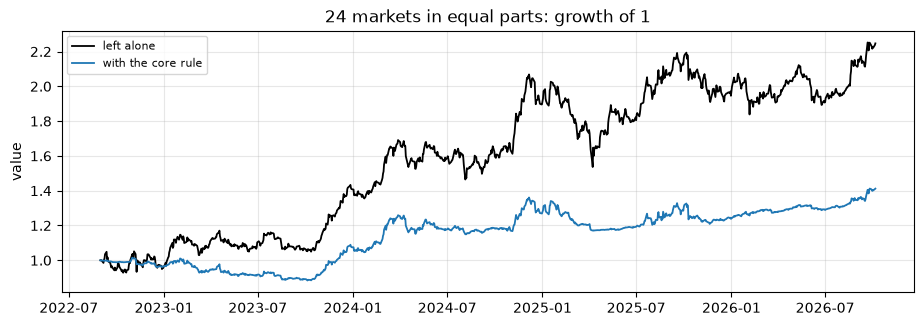

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(plain.index, (1 + plain).cumprod(), color="black", lw=1.3, label="left alone")
ax.plot(managed.index, (1 + managed).cumprod(), color="tab:blue", lw=1.3, label="with the core rule")
ax.set(title="24 markets in equal parts: growth of 1", ylabel="value")
ax.legend(fontsize=8);

## 5. A check that was not in the plan: is the *timing* doing anything?

Claim 1 compared the rule with holding everything. But the rule holds, on average,
only about half. Anyone who holds half falls about half as far, whenever they hold it.
So the fair question, which the written test did not ask, is:

**Does the rule do better than simply holding the same smaller share all the time?**

For each market, the rule is set against a fixed share equal to the rule's own average.
Same amount of cash on average; the only difference is *when* it is held.

In [9]:
rows, fixed_nets = [], {}
for symbol, frame in bars.items():
    returns = frame["close"].pct_change()
    core = shares(symbol)["core"]
    rule = nets[symbol]["core"]
    share = core.shift(1).reindex(rule.index).mean()
    fixed = ta.backtest(returns.loc[core.index], pd.Series(share, index=core.index))
    fixed_nets[symbol] = fixed
    years = len(rule) / YEAR[symbol]
    rows.append({"market": symbol, "group": GROUP_OF[symbol], "average share %": share * 100,
                 "rule fall %": ta.deepest_fall(rule) * 100, "fixed share fall %": ta.deepest_fall(fixed) * 100,
                 "rule ret/yr %": ((1 + rule).prod() ** (1 / years) - 1) * 100, "fixed share ret/yr %": ((1 + fixed).prod() ** (1 / years) - 1) * 100})
timing = pd.DataFrame(rows).set_index("market")
timing["fall: rule better by, points"] = timing["rule fall %"] - timing["fixed share fall %"]
timing["return: rule better by, points/yr"] = timing["rule ret/yr %"] - timing["fixed share ret/yr %"]
fall_gain, ret_gain = timing["fall: rule better by, points"], timing["return: rule better by, points/yr"]
print(f"Rule's deepest fall shallower than the fixed share's: {(fall_gain > 0).sum()} of {len(timing)} markets; median {fall_gain.median():+.1f} points; p = {wilcoxon(fall_gain).pvalue:.3f}")
print(f"Rule earned more than the fixed share:               {(ret_gain > 0).sum()} of {len(timing)} markets; median {ret_gain.median():+.1f} points a year; p = {wilcoxon(ret_gain).pvalue:.3f}")
print("\nMedian by group:")
print(timing.groupby("group")[["fall: rule better by, points", "return: rule better by, points/yr"]].median().to_string())
fixed_portfolio = portfolio(pd.DataFrame({s: on_sessions(fixed_nets[s]) for s in bars}))
pd.DataFrame(
    {name: [ta.deepest_fall(net) * 100, ((1 + net).prod() ** (252 / len(net)) - 1) * 100, ta.sharpe(net, 252)]
     for name, net in (("left alone", plain), ("with the core rule", managed), ("fixed smaller shares", fixed_portfolio))},
    index=["deepest fall %", "return a year %", "Sharpe"],
)

Rule's deepest fall shallower than the fixed share's: 10 of 24 markets; median -2.5 points; p = 0.136
Rule earned more than the fixed share:               4 of 24 markets; median -2.3 points a year; p = 0.013

Median by group:
             fall: rule better by, points  return: rule better by, points/yr
group                                                                       
bonds                               -1.02                              -0.84
commodities                         -8.50                              -2.13
crypto                             -25.84                              -2.23
stocks                              -0.07                              -3.23


,left alone,with the core rule,fixed smaller shares
deepest fall %,-25.72,-14.01,-11.07
return a year %,21.95,8.82,10.22
Sharpe,1.03,0.79,1.14


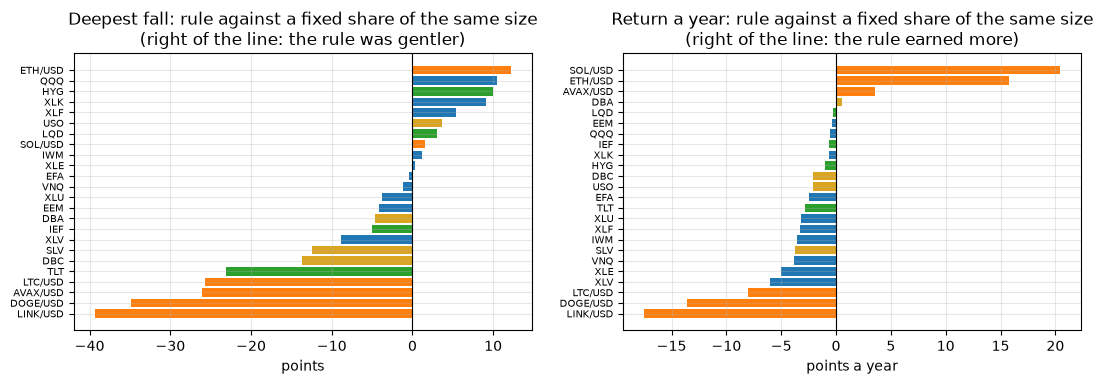

In [10]:
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 3.6))
order = timing.sort_values("fall: rule better by, points").index
left.barh(range(len(order)), timing.loc[order, "fall: rule better by, points"], color=[COLOURS[GROUP_OF[s]] for s in order])
left.set_yticks(range(len(order)), order, fontsize=7)
left.axvline(0, color="black", lw=0.8)
left.set(title="Deepest fall: rule against a fixed share of the same size\n(right of the line: the rule was gentler)", xlabel="points")
order = timing.sort_values("return: rule better by, points/yr").index
right.barh(range(len(order)), timing.loc[order, "return: rule better by, points/yr"], color=[COLOURS[GROUP_OF[s]] for s in order])
right.set_yticks(range(len(order)), order, fontsize=7)
right.axvline(0, color="black", lw=0.8)
right.set(title="Return a year: rule against a fixed share of the same size\n(right of the line: the rule earned more)", xlabel="points a year");

## 6. What the rule says today

The share the core rule would hold in each market at the latest close.

In [11]:
rows = []
for symbol, frame in bars.items():
    rules = shares(symbol)
    close = frame["close"]
    rows.append({"market": symbol, "group": GROUP_OF[symbol], "day": frame.index[-1].date(),
                 "share to hold %": rules["core"].iloc[-1] * 100, "from swings %": rules["swings"].iloc[-1] * 100,
                 "above 200-day average": bool(rules["200-day"].iloc[-1] == 1), "vs 200-day %": (close.iloc[-1] / ta.sma(close, 200).iloc[-1] - 1) * 100})
pd.DataFrame(rows).set_index("market")

,group,day,share to hold %,from swings %,above 200-day average,vs 200-day %
market,,,,,,
QQQ,stocks,2026-10-06,100.00,100.00,True,13.59
IWM,stocks,2026-10-06,100.00,100.00,True,2.13
EFA,stocks,2026-10-06,98.37,98.37,True,2.44
EEM,stocks,2026-10-06,76.01,76.01,True,8.43
XLE,stocks,2026-10-06,100.00,100.00,True,13.67
XLF,stocks,2026-10-06,100.00,100.00,True,1.28
XLK,stocks,2026-10-06,100.00,100.00,True,22.28
XLV,stocks,2026-10-06,100.00,100.00,True,7.34
XLU,stocks,2026-10-06,0.00,82.05,False,-5.98


## 7. The result

| claim | by the written test | what it means |
|---|---|---|
| 1. the core rule makes the deepest fall shallower than holding everything | **passed**: shallower in 23 of 24 markets, by 15 points in the median market, in all four groups | true, but see the check |
| 2. news and indicators improve on the core rule | **none passed** | stepping back around events and the stochastic made it measurably worse; fair value gaps and order blocks added nothing and let the falls back in |
| 3. it works on a portfolio | **passed** as written: deepest fall 26% to 14% | at the price of return a year going from about 22% to about 9% |
| the check in section 5 | not in the plan | **a fixed smaller share did as well or better** |

**The check is the real finding.** The rule holds about half on average, and anyone who
holds half falls about half as far. Set against simply holding that same smaller share
all the time:

- the rule's deepest fall was shallower in only 10 of 24 markets;
- the rule earned *less* in 20 of 24, by about 2 points a year in the median market, and
  that difference is more than luck;
- on the portfolio, fixed smaller shares fell 11% and earned 10% a year; the rule fell
  14% and earned 9%.

So the protection came from **how much** was held, not from **when**. The moving
average and the swings reading chose the wrong moments about as often as the right
ones: they step out after a fall has happened and step back in after part of the
recovery. This is what Cederburg and others found in 2020 for the same idea.

**The written test was too easy, and that is my mistake.** Comparing with "hold
everything" lets any rule that holds less look good. It should have been compared with
a fixed share of the same size from the start. The rule passed the test I wrote; it
does not pass the test I should have written.

**My guess beforehand, checked.** Right that claim 1 would pass with less return in
most markets, and that no add-on would pass. Wrong about where it would be clearest: I
said crypto and stocks, and against a fixed share crypto is where the rule did *worst*
on the fall. I did not foresee that the timing itself would turn out to add nothing.

## 8. What this means for "when to hold cash, and how much"

**How much: this can be answered, and it matters most.** The share held decides how far
a portfolio falls and how much it earns, almost in proportion. That is a choice about
what fall a person can live with, and RADAR can show it exactly: "holding 60% of this
mix would have fallen about this far and earned about this much".

**When: nothing tested here beats not timing at all.** Not the 200-day average, not
swings, not Fed and data days, not the stochastic, not fair value gaps, not order
blocks, and (notebooks 11 and 12) not a model. An alert saying "move to cash now" would
rest on a rule that, on 24 fresh markets, did no better than having held that cash all
along and earned less.

**When to put cash back.** The three "buy" triggers all did the same thing: they raised
the share held (from about 54% to between 60% and 79%), which brought the deeper falls
back, without a better return for the risk. They are a way of holding more, not a way
of choosing the moment.

**What remains true and useful.** Swings can be forecast (notebook 4), so the *size* of
the next move can be. A person can therefore be told "the next week is likely to be
rougher than usual" and can decide to hold less through it. That is a statement about
risk, with a record behind it. It is not a statement that the price will fall.

**Limits.** Ten years for funds and five for coins, one long rising stretch for most of
them; markets that move together; and a deepest fall is one event per market. A fixed
share is compared here using the rule's own average, which is only known afterwards.
The outside data the user agreed to (funding rates, order flow, positioning) has not
been tested yet and is the next thing to try.